# Visualize EMD results for each comparison

We will visualize the signed EMD results for each comparison as ___ plots.

In [1]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(arrow))

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘tidyr’ was built under R version 4.2.3”
Warning message:
“package ‘arrow’ was built under R version 4.2.3”


## Set output directory for figures

In [2]:
output_dir <- "./emd_figures"
if (!dir.exists(output_dir)) {
    dir.create(output_dir, recursive = TRUE)
}

## Visualize failing DMSO cells (reference) compared to failing drug_x cells

In [3]:
failing_vs_failing_drug_x_emd_df <- read_parquet("emd_results/failing_vs_failing_drug_x_emd.parquet")

dim(failing_vs_failing_drug_x_emd_df)
head(failing_vs_failing_drug_x_emd_df)

[1] 1887    6

feature,signed_emd,compartment,feature_group,measurement,organelle
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Cytoplasm_AreaShape_Area,-0.04233140,Cytoplasm,AreaShape,Area,Other
Cytoplasm_AreaShape_BoundingBoxArea,0.16183602,Cytoplasm,AreaShape,BoundingBoxArea,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_X,0.03390860,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_Y,0.04770960,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_X,-0.03139711,Cytoplasm,AreaShape,BoundingBoxMinimum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_Y,0.01406130,Cytoplasm,AreaShape,BoundingBoxMinimum,Other


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


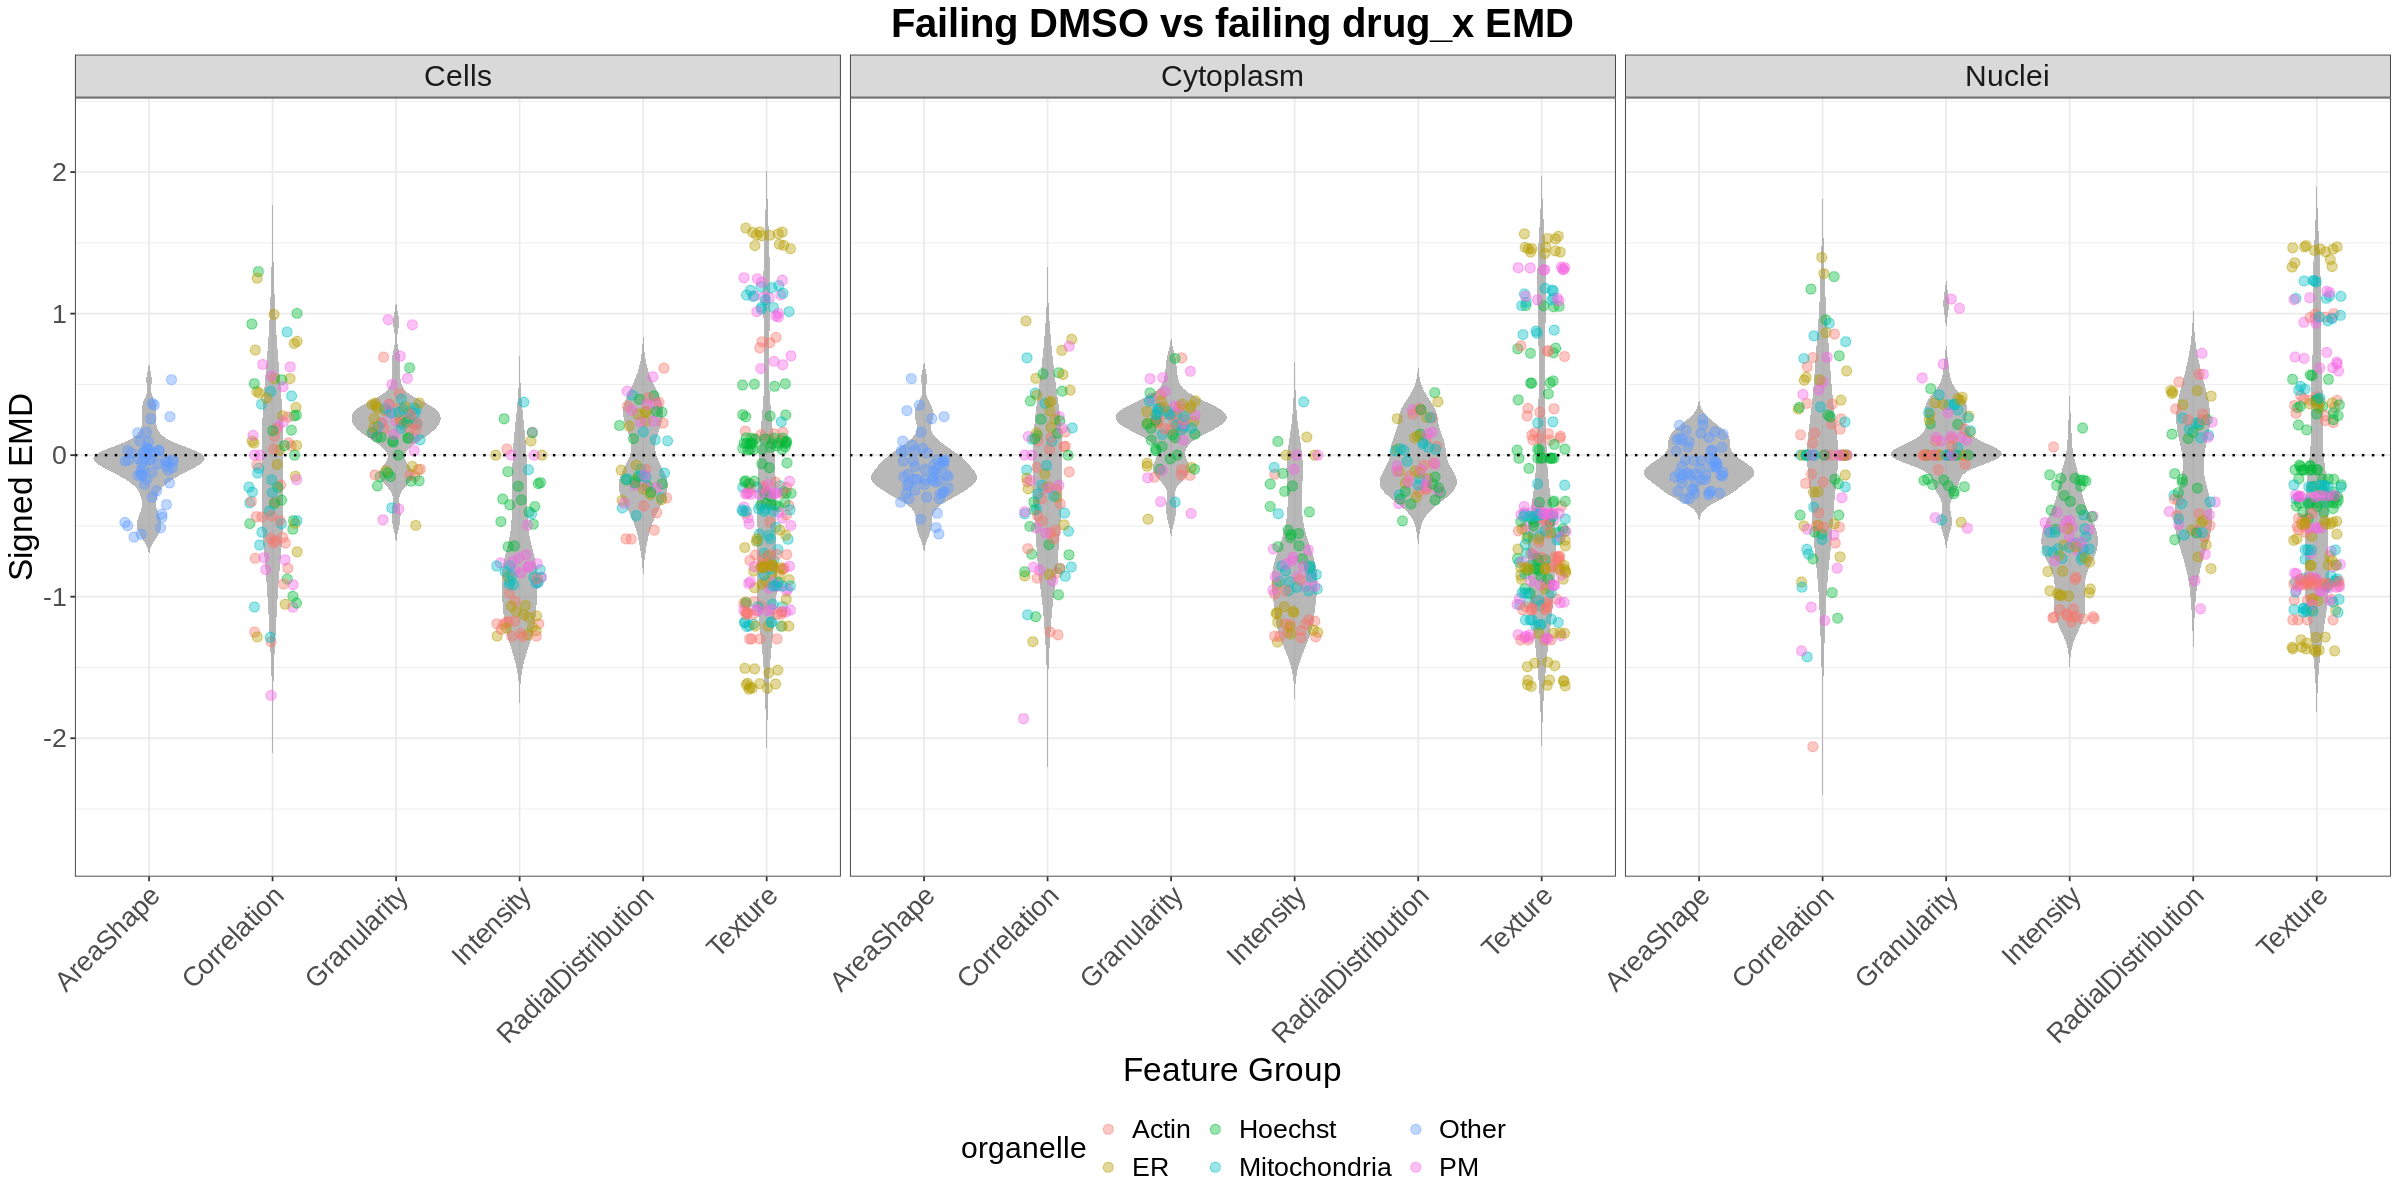

In [4]:
height <- 10
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

failing_vs_failing_drug_x_plot <- ggplot(failing_vs_failing_drug_x_emd_df, aes(x = feature_group, y = signed_emd)) +
    geom_violin(trim = FALSE, fill = "grey60", color = NA, alpha = 0.7) +
    geom_jitter(aes(color = organelle), width = 0.2, alpha = 0.4, size = 2.5) +
    geom_hline(yintercept = 0, linetype = "dotted", color = "black", size = 0.7) +
    facet_wrap(~ compartment) +
    theme_bw() +
    labs(
        title = "Failing DMSO vs failing drug_x EMD",
        x = "Feature Group",
        y = "Signed EMD"
    ) +
    theme(
        legend.position = "bottom",
        plot.title = element_text(size = 24, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 18),
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_failing_drug_x_emd_violin_plot.png"),
    plot = failing_vs_failing_drug_x_plot,
    width = width,
    height = height,
    dpi = 500
)

failing_vs_failing_drug_x_plot

In [5]:
emd_direction_fraction <- failing_vs_failing_drug_x_emd_df %>%
  mutate(direction = case_when(
    signed_emd > 0.05 ~ "increased",
    signed_emd < -0.05 ~ "decreased",
    TRUE ~ "no change"
  )) %>%
  group_by(feature_group, compartment, direction) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(feature_group, compartment) %>%
  mutate(fraction = count / sum(count)) %>%
  ungroup()


head(emd_direction_fraction)

feature_group,compartment,direction,count,fraction
<chr>,<chr>,<chr>,<int>,<dbl>
AreaShape,Cells,decreased,24,0.4444444
AreaShape,Cells,increased,9,0.1666667
AreaShape,Cells,no change,21,0.3888889
AreaShape,Cytoplasm,decreased,35,0.6481481
AreaShape,Cytoplasm,increased,8,0.1481481
AreaShape,Cytoplasm,no change,11,0.2037037


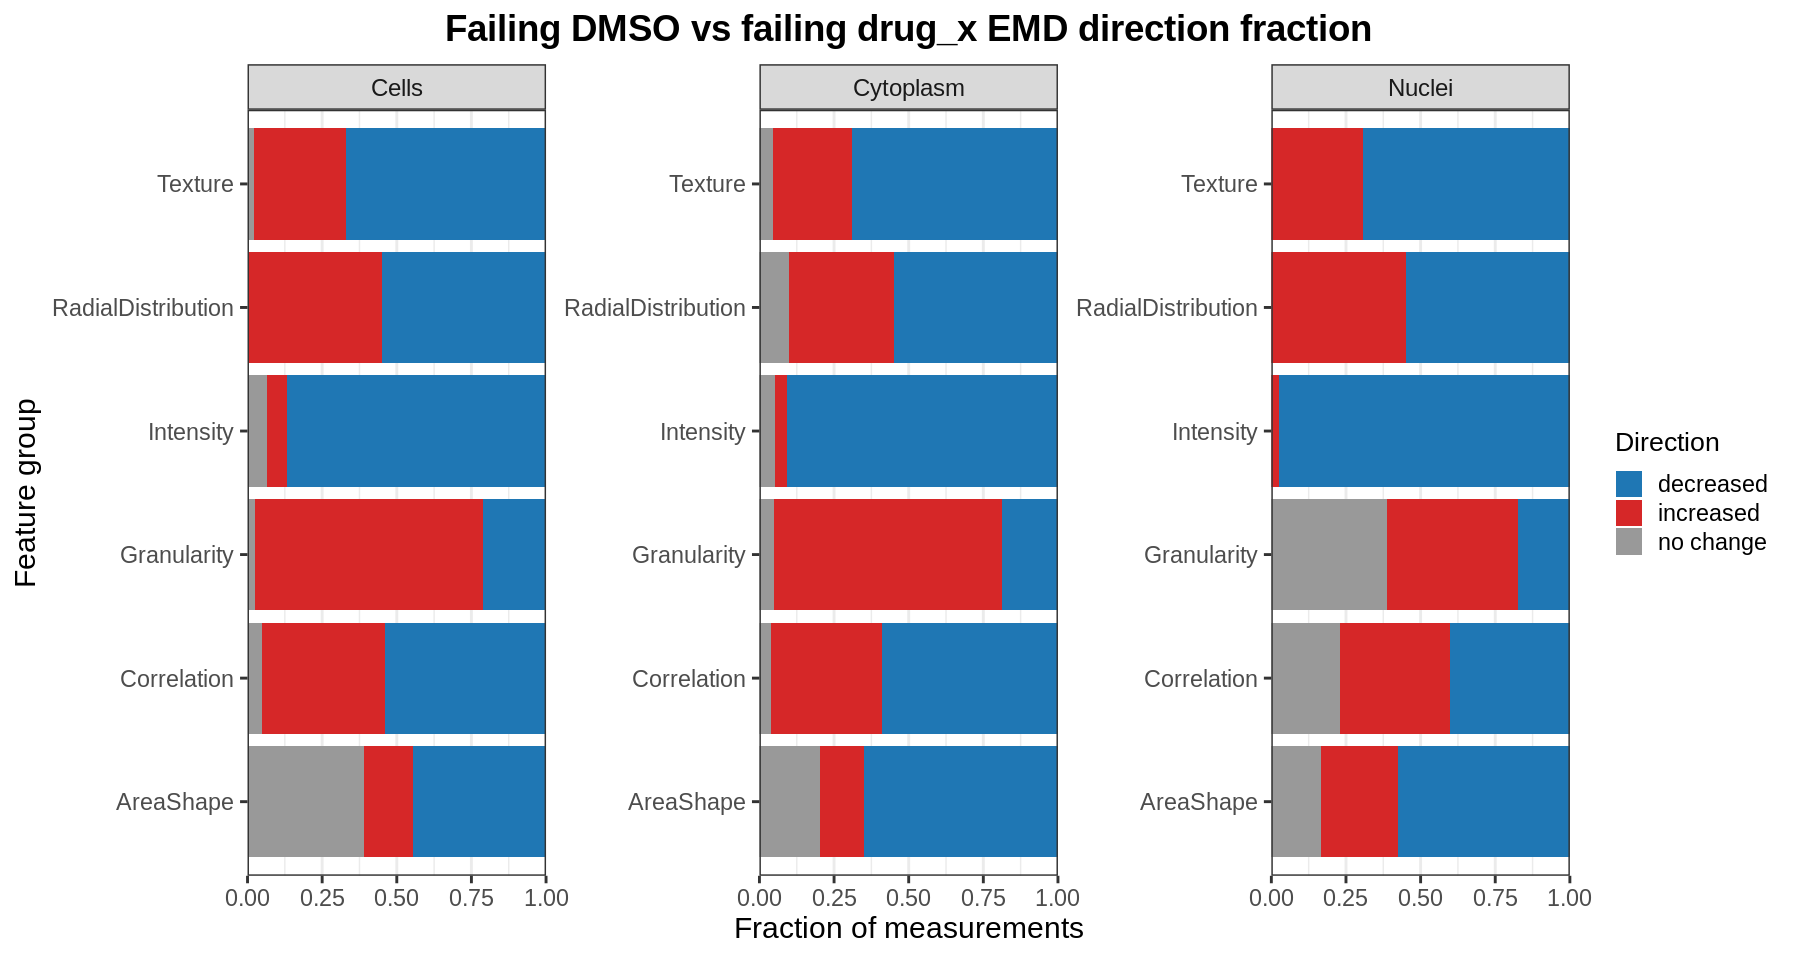

In [6]:
height <- 8
width <- 15
options(repr.plot.width = width, repr.plot.height = height)

emd_direction_fraction_plot <- ggplot(emd_direction_fraction, aes(x = fraction, y = feature_group, fill = direction)) +
    geom_bar(stat = "identity", position = "stack") +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    labs(
        title = "Failing DMSO vs failing drug_x EMD direction fraction",
        x = "Fraction of measurements",
        y = "Feature group",
        fill = "Direction"
    ) +
    facet_wrap(~ compartment, scales = "free_y") +
    theme_bw(base_size = 18) +
    scale_fill_manual(
    values = c(
        "increased" = "#D62728",  # red
        "decreased" = "#1F77B4",  # blue
        "no change" = "grey60"
        )
    ) +
    theme(
        plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 18),
        axis.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        legend.text = element_text(size = 14)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_failing_drug_x_emd_fraction_bar_plot.png"),
    plot = emd_direction_fraction_plot,
    width = width,
    height = height,
    dpi = 500
)

emd_direction_fraction_plot

## Visualize healthy DMSO cells (reference) compared to failing drug_x cells

In [7]:
healthy_vs_failing_drug_x_emd_df <- read_parquet("emd_results/healthy_vs_failing_drug_x_emd.parquet")

dim(healthy_vs_failing_drug_x_emd_df)
head(healthy_vs_failing_drug_x_emd_df)

[1] 1887    6

feature,signed_emd,compartment,feature_group,measurement,organelle
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Cytoplasm_AreaShape_Area,0.11387851,Cytoplasm,AreaShape,Area,Other
Cytoplasm_AreaShape_BoundingBoxArea,0.36078573,Cytoplasm,AreaShape,BoundingBoxArea,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_X,0.07507932,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_Y,0.12354190,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_X,0.06942761,Cytoplasm,AreaShape,BoundingBoxMinimum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_Y,0.14964953,Cytoplasm,AreaShape,BoundingBoxMinimum,Other


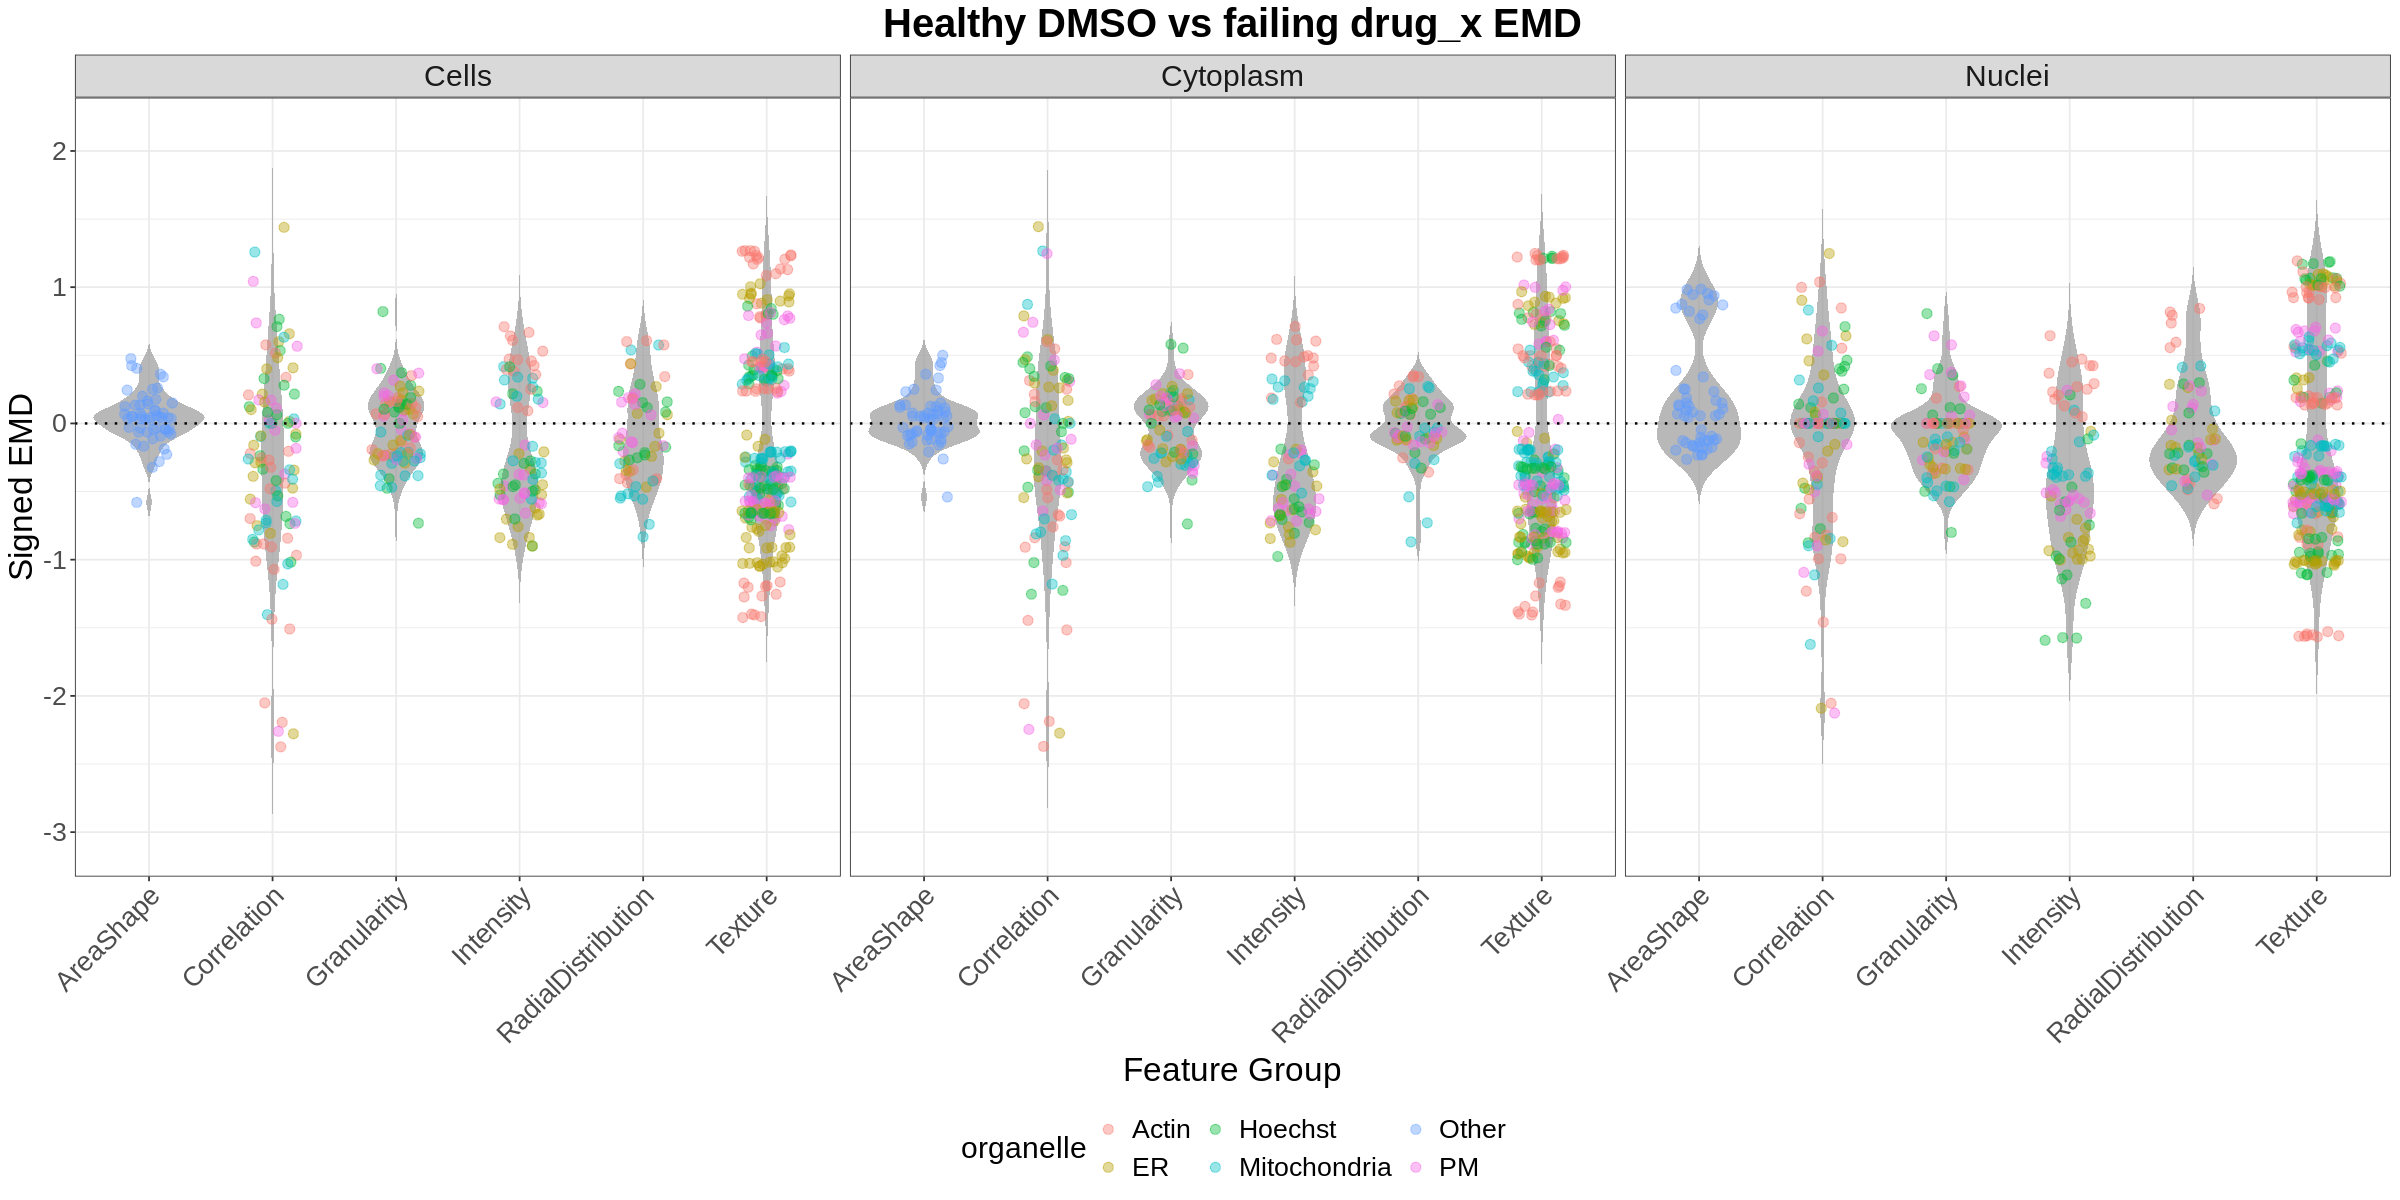

In [8]:
height <- 10
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

healthy_vs_failing_drug_x_plot <- ggplot(healthy_vs_failing_drug_x_emd_df, aes(x = feature_group, y = signed_emd)) +
    geom_violin(trim = FALSE, fill = "grey60", color = NA, alpha = 0.7) +
    geom_jitter(aes(color = organelle), width = 0.2, alpha = 0.4, size = 2.5) +
    geom_hline(yintercept = 0, linetype = "dotted", color = "black", size = 0.7) +
    facet_wrap(~ compartment) +
    theme_bw() +
    labs(
        title = "Healthy DMSO vs failing drug_x EMD",
        x = "Feature Group",
        y = "Signed EMD"
    ) +
    theme(
        legend.position = "bottom",
        plot.title = element_text(size = 24, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 18),
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "healthy_vs_failing_drug_x_emd_violin_plot.png"),
    plot = healthy_vs_failing_drug_x_plot,
    width = width,
    height = height,
    dpi = 500
)

healthy_vs_failing_drug_x_plot

In [9]:
hvf_emd_direction_fraction <- healthy_vs_failing_drug_x_emd_df %>%
  mutate(direction = case_when(
    signed_emd > 0.05 ~ "increased",
    signed_emd < -0.05 ~ "decreased",
    TRUE ~ "no change"
  )) %>%
  group_by(feature_group, compartment, direction) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(feature_group, compartment) %>%
  mutate(fraction = count / sum(count)) %>%
  ungroup()


head(hvf_emd_direction_fraction)

feature_group,compartment,direction,count,fraction
<chr>,<chr>,<chr>,<int>,<dbl>
AreaShape,Cells,decreased,13,0.2407407
AreaShape,Cells,increased,25,0.4629630
AreaShape,Cells,no change,16,0.2962963
AreaShape,Cytoplasm,decreased,21,0.3888889
AreaShape,Cytoplasm,increased,25,0.4629630
AreaShape,Cytoplasm,no change,8,0.1481481


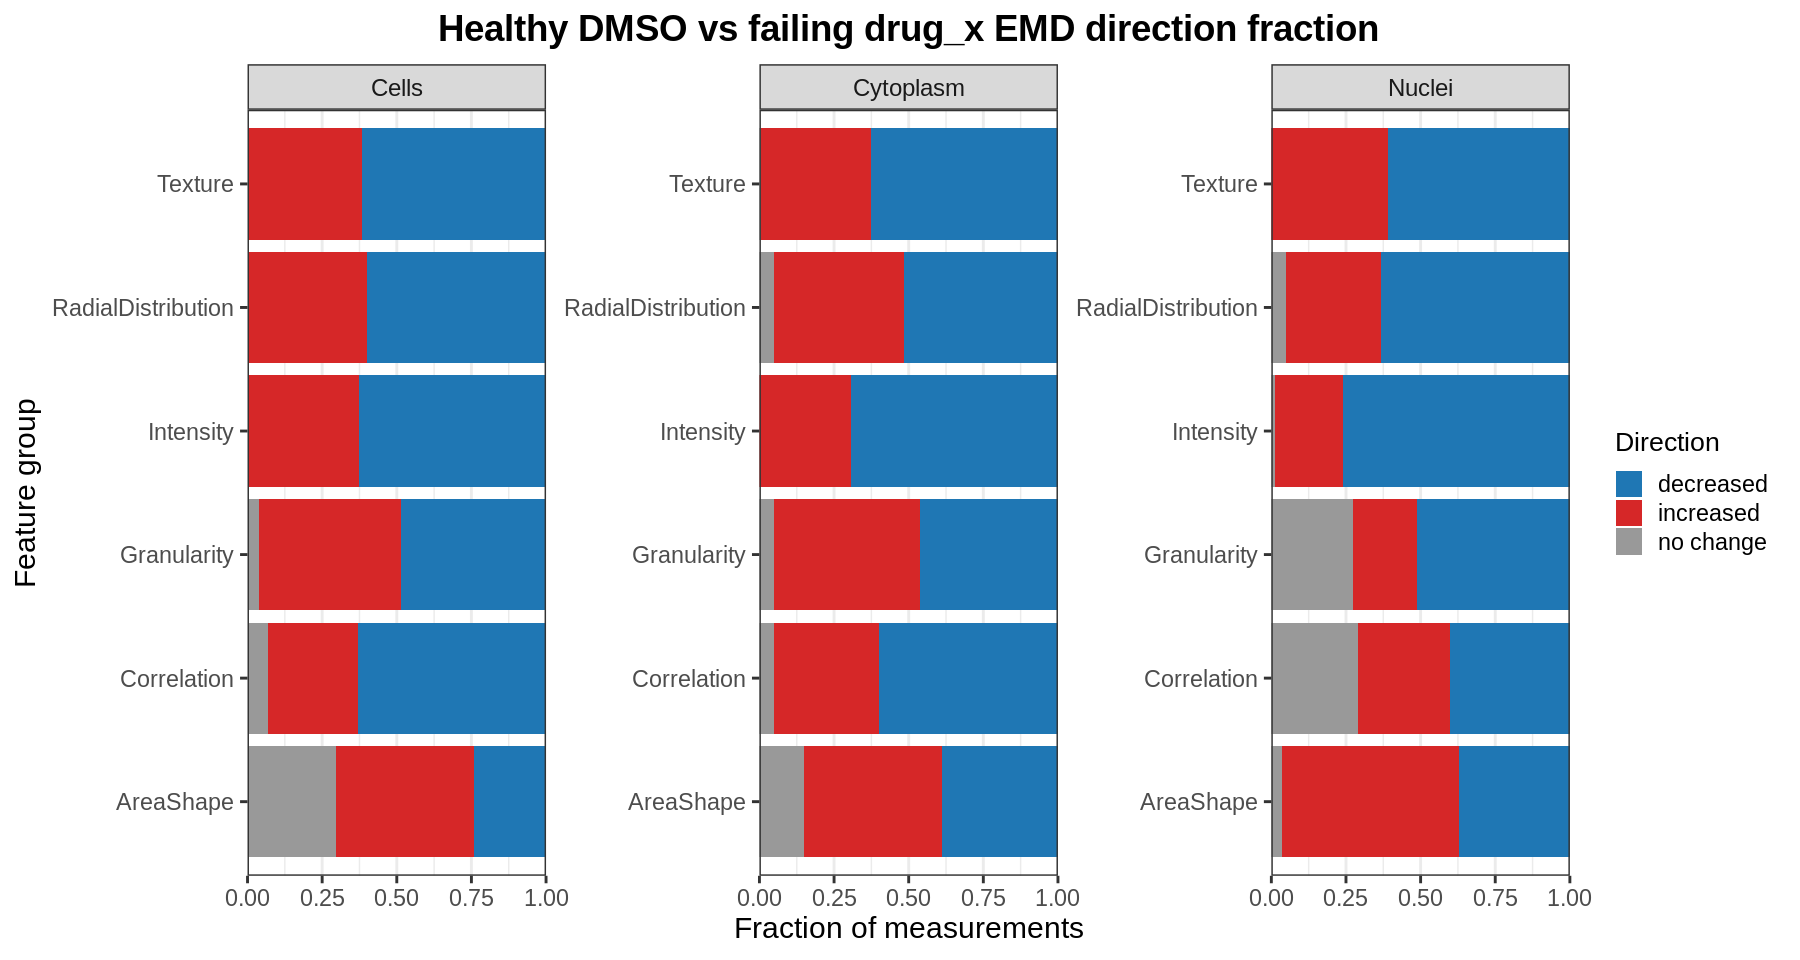

In [10]:
height <- 8
width <- 15
options(repr.plot.width = width, repr.plot.height = height)

hvf_emd_direction_fraction_plot <- ggplot(hvf_emd_direction_fraction, aes(x = fraction, y = feature_group, fill = direction)) +
    geom_bar(stat = "identity", position = "stack") +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    labs(
        title = "Healthy DMSO vs failing drug_x EMD direction fraction",
        x = "Fraction of measurements",
        y = "Feature group",
        fill = "Direction"
    ) +
    facet_wrap(~ compartment, scales = "free_y") +
    theme_bw(base_size = 18) +
    scale_fill_manual(
    values = c(
        "increased" = "#D62728",  # red
        "decreased" = "#1F77B4",  # blue
        "no change" = "grey60"
        )
    ) +
    theme(
        plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 18),
        axis.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        legend.text = element_text(size = 14)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "healthy_vs_failing_drug_x_emd_fraction_bar_plot.png"),
    plot = hvf_emd_direction_fraction_plot,
    width = width,
    height = height,
    dpi = 500
)

hvf_emd_direction_fraction_plot

## Visualize failing DMSO cells (reference) compared to healthy DMSO cells

In [11]:
failing_vs_healthy_DMSO_emd_df <- read_parquet("emd_results/failing_vs_healthy_DMSO_emd.parquet")

dim(failing_vs_healthy_DMSO_emd_df)
head(failing_vs_healthy_DMSO_emd_df)

[1] 1887    6

feature,signed_emd,compartment,feature_group,measurement,organelle
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Cytoplasm_AreaShape_Area,-0.15172402,Cytoplasm,AreaShape,Area,Other
Cytoplasm_AreaShape_BoundingBoxArea,0.42672994,Cytoplasm,AreaShape,BoundingBoxArea,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_X,-0.04893365,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMaximum_Y,-0.07852257,Cytoplasm,AreaShape,BoundingBoxMaximum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_X,-0.09361491,Cytoplasm,AreaShape,BoundingBoxMinimum,Other
Cytoplasm_AreaShape_BoundingBoxMinimum_Y,-0.13768409,Cytoplasm,AreaShape,BoundingBoxMinimum,Other


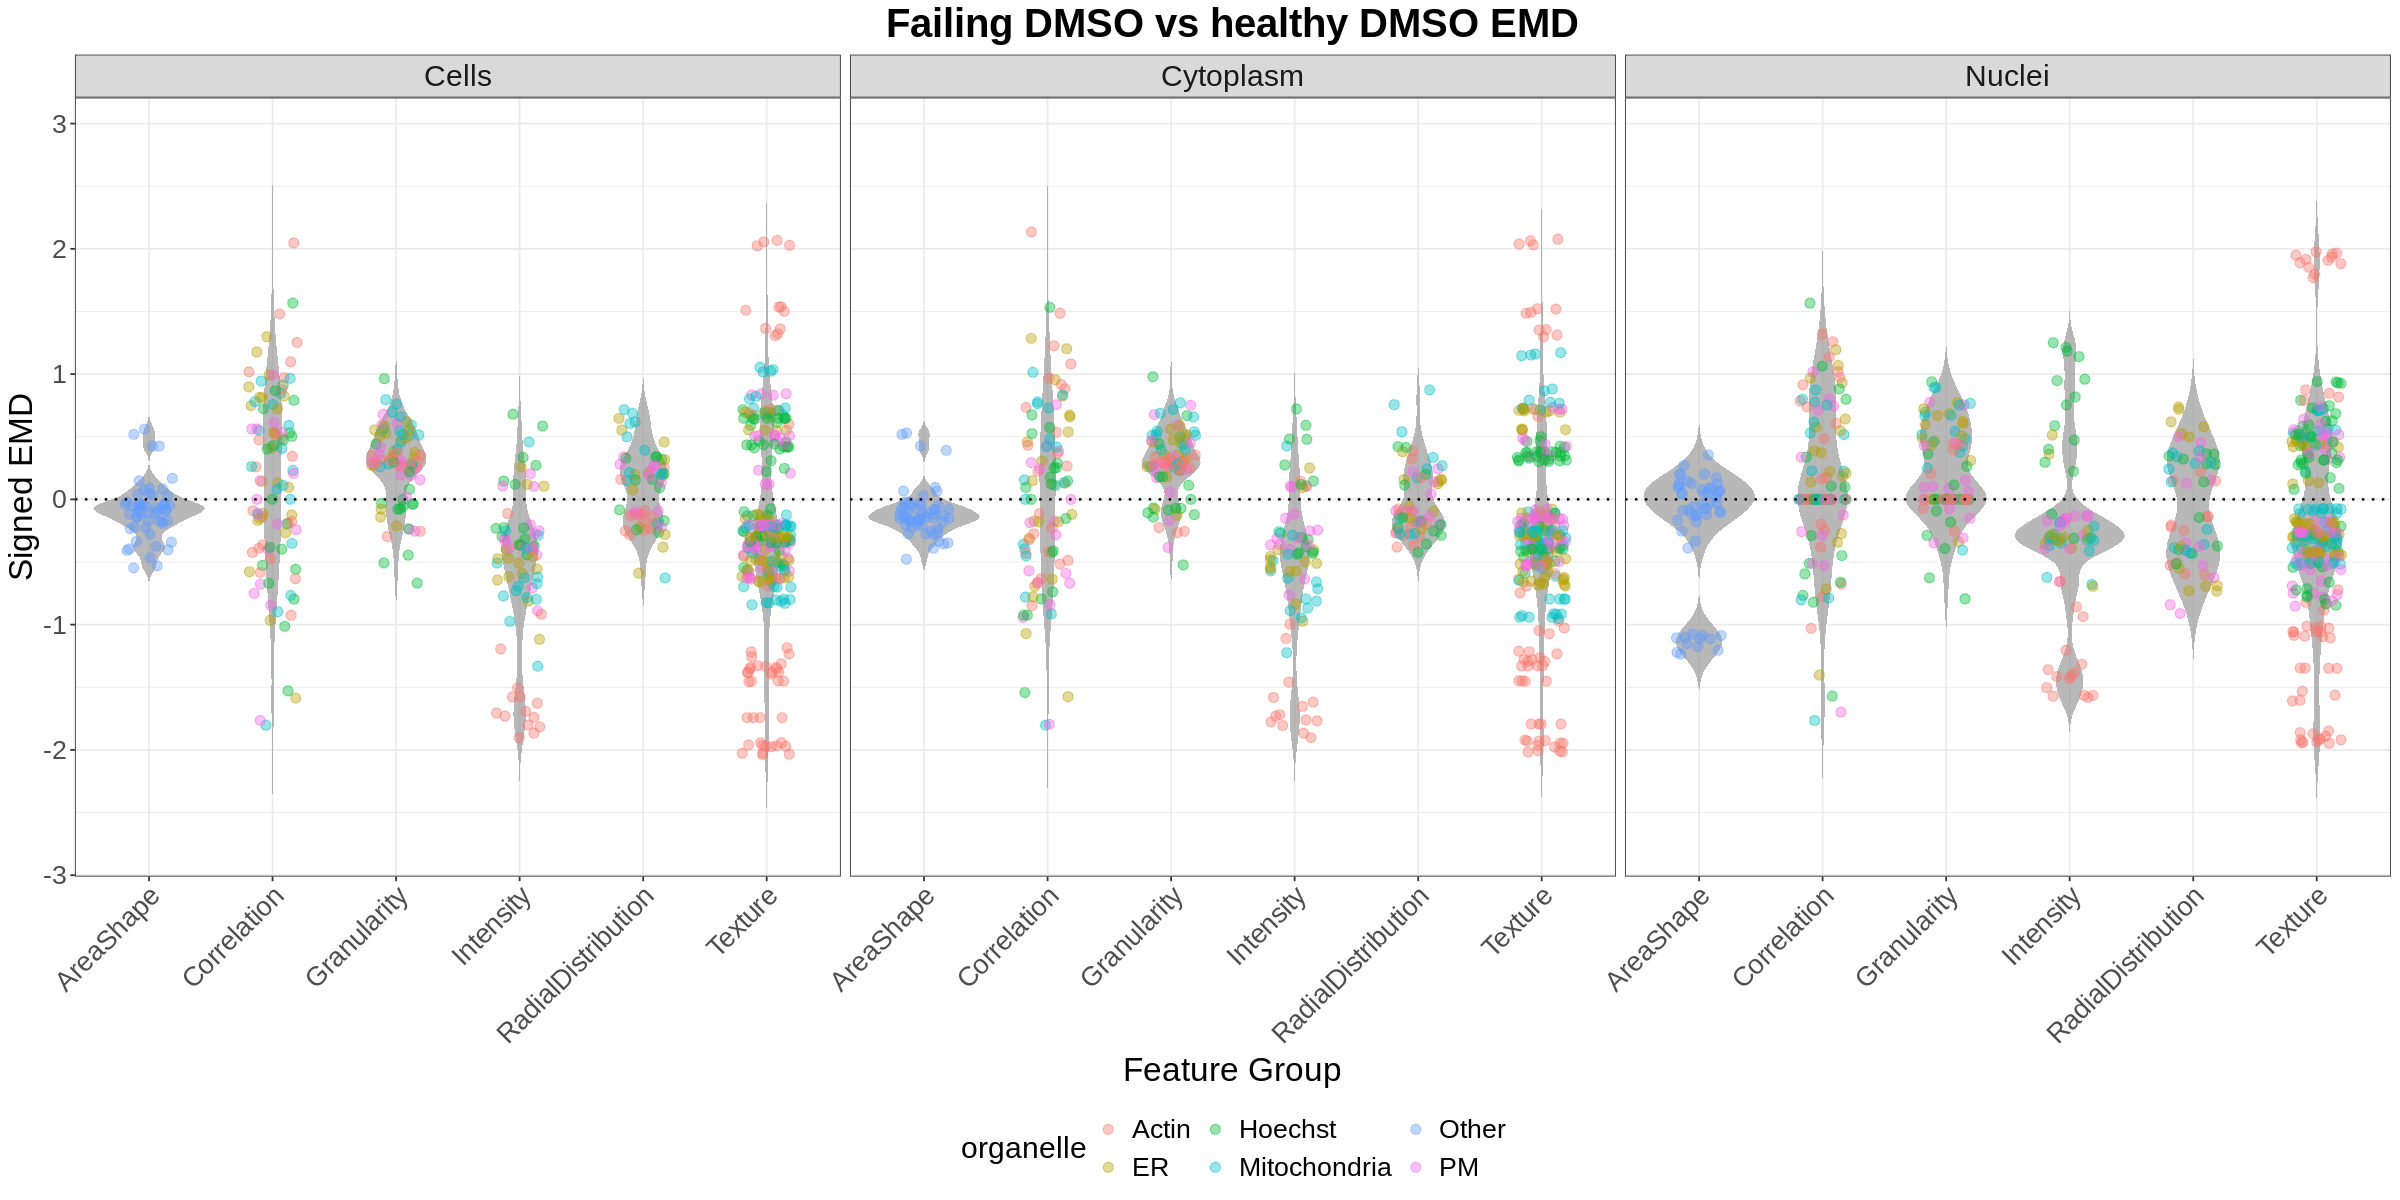

In [12]:
height <- 10
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

failing_vs_healthy_DMSO_plot <- ggplot(failing_vs_healthy_DMSO_emd_df, aes(x = feature_group, y = signed_emd)) +
    geom_violin(trim = FALSE, fill = "grey60", color = NA, alpha = 0.7) +
    geom_jitter(aes(color = organelle), width = 0.2, alpha = 0.4, size = 2.5) +
    geom_hline(yintercept = 0, linetype = "dotted", color = "black", size = 0.7) +
    facet_wrap(~ compartment) +
    theme_bw() +
    labs(
        title = "Failing DMSO vs healthy DMSO EMD",
        x = "Feature Group",
        y = "Signed EMD"
    ) +
    theme(
        legend.position = "bottom",
        plot.title = element_text(size = 24, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text = element_text(size = 18),
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_healthy_DMSO_emd_violin_plot.png"),
    plot = failing_vs_healthy_DMSO_plot,
    width = width,
    height = height,
    dpi = 500
)

failing_vs_healthy_DMSO_plot

In [13]:
fvh_emd_direction_fraction <- failing_vs_healthy_DMSO_emd_df %>%
  mutate(direction = case_when(
    signed_emd > 0.05 ~ "increased",
    signed_emd < -0.05 ~ "decreased",
    TRUE ~ "no change"
  )) %>%
  group_by(feature_group, compartment, direction) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(feature_group, compartment) %>%
  mutate(fraction = count / sum(count)) %>%
  ungroup()


head(fvh_emd_direction_fraction)

feature_group,compartment,direction,count,fraction
<chr>,<chr>,<chr>,<int>,<dbl>
AreaShape,Cells,decreased,33,0.6111111
AreaShape,Cells,increased,9,0.1666667
AreaShape,Cells,no change,12,0.2222222
AreaShape,Cytoplasm,decreased,40,0.7407407
AreaShape,Cytoplasm,increased,7,0.1296296
AreaShape,Cytoplasm,no change,7,0.1296296


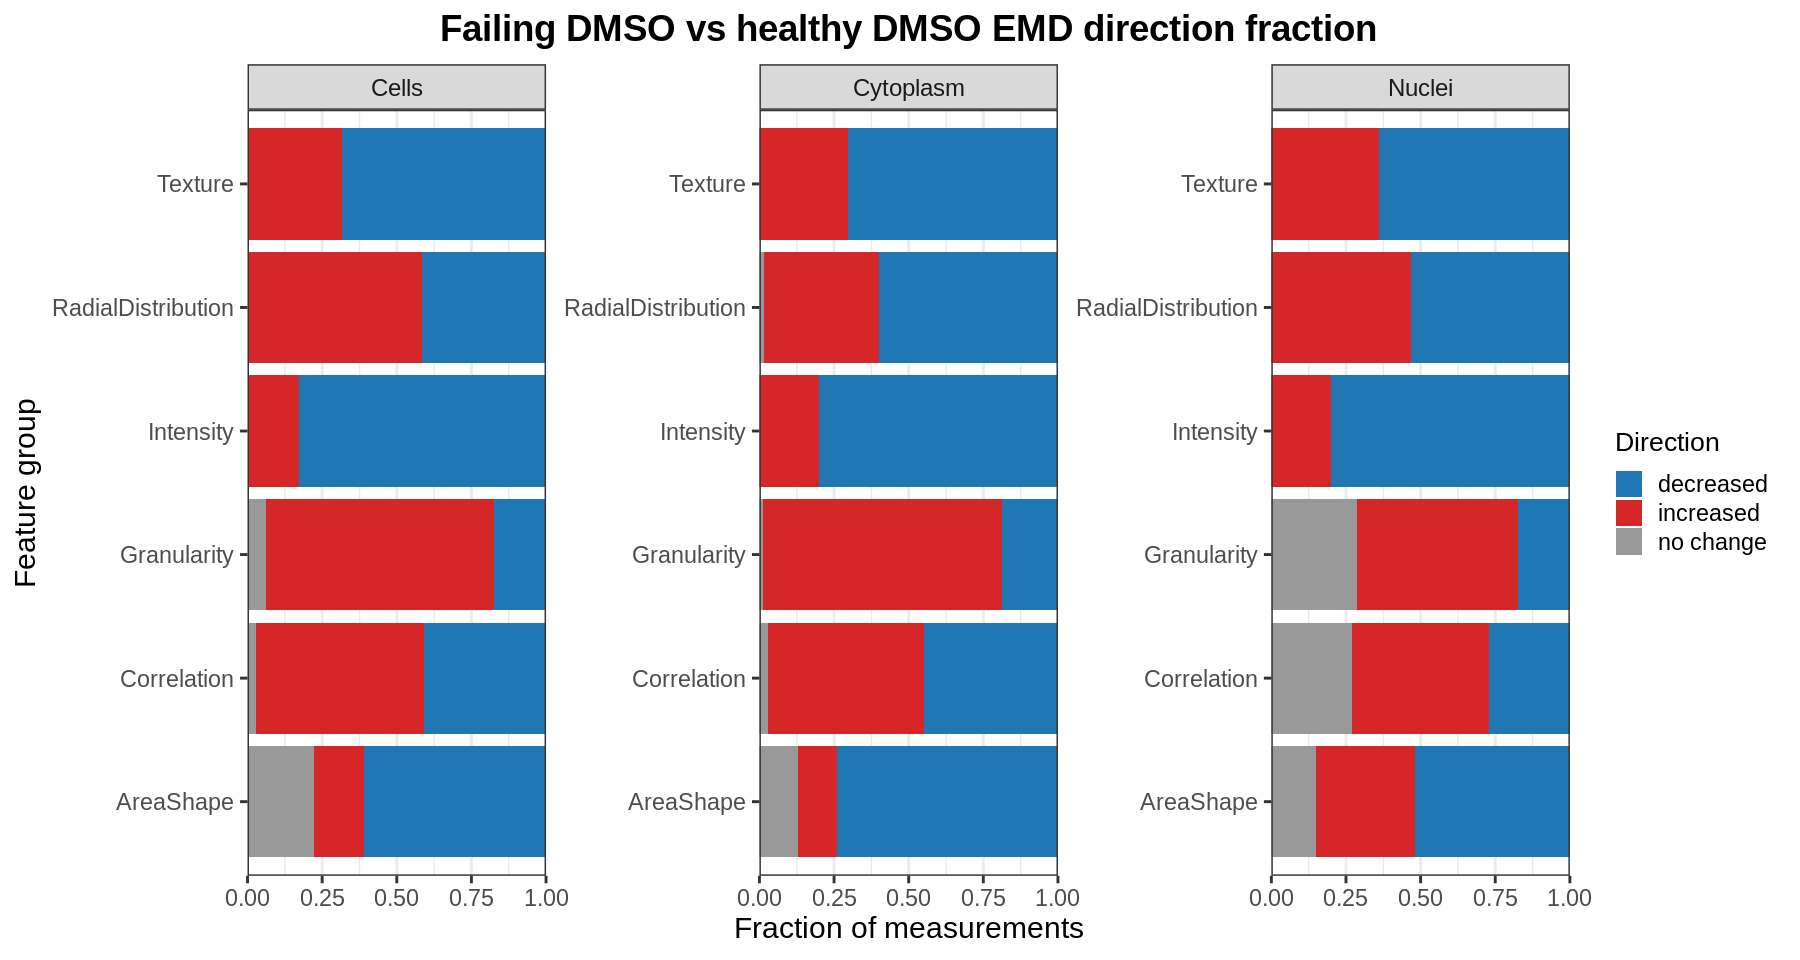

In [14]:
height <- 8
width <- 15
options(repr.plot.width = width, repr.plot.height = height)

fvh_emd_direction_fraction_plot <- ggplot(fvh_emd_direction_fraction, aes(x = fraction, y = feature_group, fill = direction)) +
    geom_bar(stat = "identity", position = "stack") +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    labs(
        title = "Failing DMSO vs healthy DMSO EMD direction fraction",
        x = "Fraction of measurements",
        y = "Feature group",
        fill = "Direction"
    ) +
    facet_wrap(~ compartment, scales = "free_y") +
    theme_bw(base_size = 18) +
    scale_fill_manual(
    values = c(
        "increased" = "#D62728",  # red
        "decreased" = "#1F77B4",  # blue
        "no change" = "grey60"
        )
    ) +
    theme(
        plot.title = element_text(size = 22, face = "bold", hjust = 0.5),
        axis.title = element_text(size = 18),
        axis.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        legend.text = element_text(size = 14)
    )

# Save the plot
ggsave(
    filename = file.path(output_dir, "failing_vs_healthy_DMSO_emd_fraction_bar_plot.png"),
    plot = fvh_emd_direction_fraction_plot,
    width = width,
    height = height,
    dpi = 500
)

fvh_emd_direction_fraction_plot